<a href="https://colab.research.google.com/github/OsvaldoCr99/Challenge-Introducci-n-a-las-Funciones-CRUD-de-Agenda-/blob/main/Challenge_Introducci%C3%B3n_a_la_Estad%C3%ADstica_Inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**

Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1wBQxgzbO4PV0meYNF_UCzhk7p6yC_xGu?usp=sharing).


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [34]:
# Importar librerías

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
# Importar dataset

df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [36]:
# Importar módulo

from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [37]:
# Separaración de grupos

propinas_fumadores = df_tips[df_tips['smoker'] == 'Yes']['tip']
propinas_no_fumadores = df_tips[df_tips['smoker'] == 'No']['tip']

In [38]:
# Aplicar Prueba T de Student

t_stat, p_value = stats.ttest_ind(propinas_fumadores, propinas_no_fumadores)

print(f"Estadístico T: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Estadístico T: 0.0922
P-Value: 0.9266


In [39]:
# Interpretación automática

if p_value < 0.01:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia muy significativa entre las propinas de ambos grupos.")
elif p_value >= 0.01 and p_value < 0.05:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia altamente significativa entre las propinas de ambos grupos.")
elif p_value >= 0.05 and p_value < 0.10:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia moderadamente significativa entre las propinas de ambos grupos.")
else:
    print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
    print("No hay evidencia suficiente para decir que las propinas son diferentes.")


Conclusión: No podemos rechazar la Hipótesis Nula.
No hay evidencia suficiente para decir que las propinas son diferentes.


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [40]:
x = df_tips['total_bill']
y = df_tips['tip']

# Definir regresión lineal

linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')

y = 0.10502451738435338 x + 0.920269613554673


In [41]:
# Predicción de valores con regresión lineal

tb_pred_lr = int(input('Agrega el valor del total de la cuenta que deseas predecir la propina: '))
y_pred_lr = round(beta * tb_pred_lr + alpha, 2)

print(f'La propina será de {y_pred_lr}')

Agrega el valor del total de la cuenta que deseas predecir la propina: 2
La propina será de 1.13


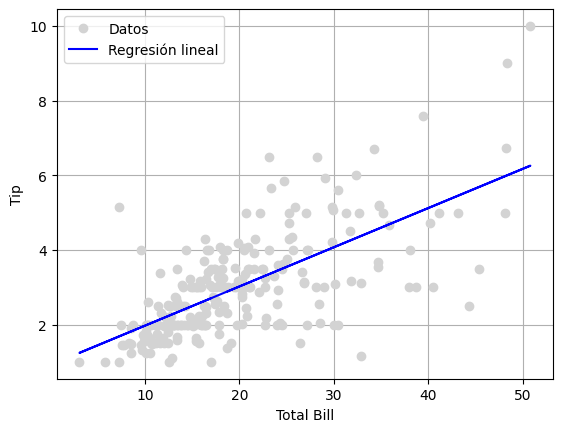

In [42]:
# Visualizar regresión lineal

plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta*x + alpha, color = 'blue', label = 'Regresión lineal')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [43]:
# Iterar pérdida de la regresión lineal

num_iteraciones = 100
perdida = []

for i in range(num_iteraciones):

    y_pred = np.polyval(linear_regression, x)
    error = ((y - y_pred) ** 2).mean()
    perdida.append(error)

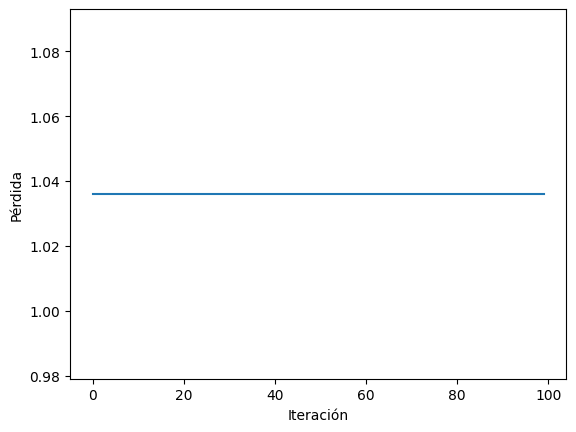

In [44]:
# Visualizar pérdida de la regresión lineal

plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [45]:
# Definir parámetros

tamaño_paso = 0.001
theta_0 = 0
theta_1 = 0

perdida = []

La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [46]:
# Realizar algoritmo del descenso de gradiente

num_iteraciones = 100
n = len(x) # Define n as the number of data points

for i in range(num_iteraciones):
    y_pred = theta_1 * x + theta_0
    error = ((y_pred - y) ** 2).mean()
    perdida.append(error)

    d_theta_0 = (2 / n) * np.sum(y_pred - y)
    d_theta_1 = (2 / n) * np.sum((y_pred - y) * x)

    theta_0 = theta_0 - tamaño_paso * d_theta_0
    theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 0.14222421840347957 x + 0.036159981060935556


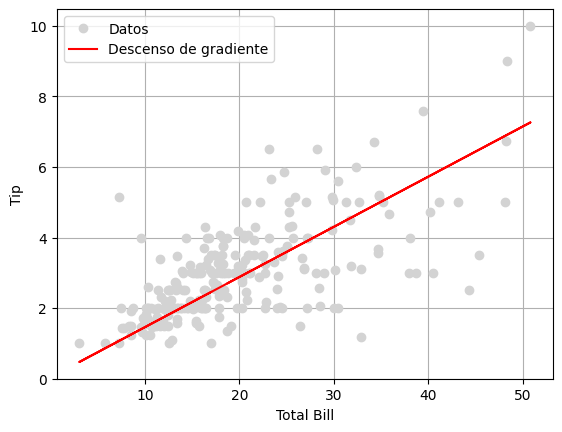

In [47]:
# Visualizar la regresión lineal por descenso de gradiente

plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [48]:
# Predicción de valores con descenso de gradiente

tb_pred_gd = int(input('Agrega el valor del total de la cuenta que deseas predecir la propina: '))
y_pred_gd = round(theta_1 * tb_pred_gd + theta_0, 2)

print(f'La propina será de {y_pred_gd}')

Agrega el valor del total de la cuenta que deseas predecir la propina: 1000
La propina será de 142.26


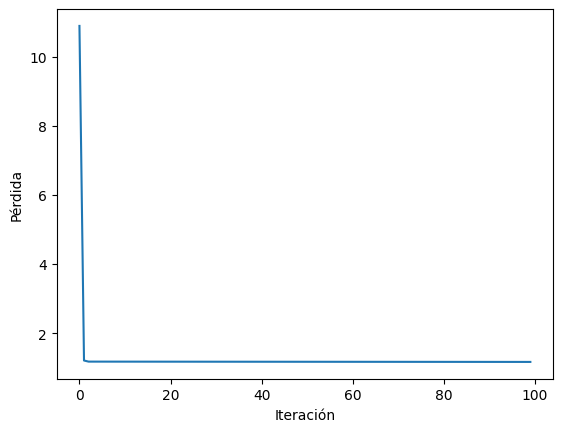

In [49]:
# Visualizar las pérdidas

plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

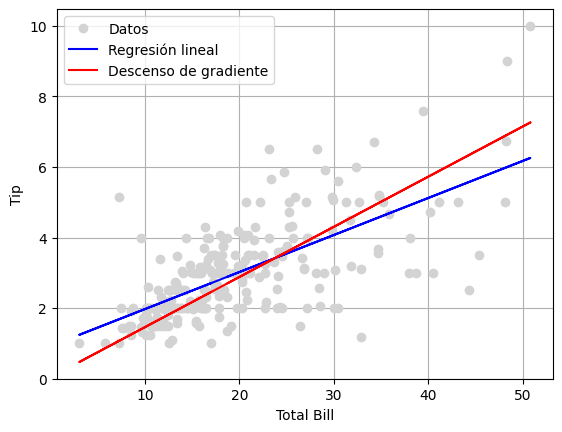

In [50]:
# Comparar las rectas obtenidas por los algoritmos

plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta*x + alpha, color = 'blue', label = 'Regresión lineal')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

In [51]:
# Importar librerías

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [52]:
# Importar librerías


**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [53]:
# Importar dataset

df_taxis = sns.load_dataset('taxis')
df_taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [54]:
# Importar módulo

from scipy import stats

In [55]:
# Separación de grupos

distancia_amarillo = df_taxis[df_taxis['color'] == 'yellow']['distance']
distancia_verde = df_taxis[df_taxis['color'] == 'green']['distance']

In [56]:
# Aplicar Prueba T de Student

t_stat_dist, p_value_dist = stats.ttest_ind(distancia_amarillo, distancia_verde)

print(f"Estadístico T: {t_stat_dist:.4f}")
print(f"P-Value: {p_value_dist:.4f}")

Estadístico T: -3.4060
P-Value: 0.0007


In [57]:
if p_value_dist < 0.01:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia muy significativa entre las distancias recorridas de ambos grupos de taxis.")
elif p_value_dist >= 0.01 and p_value_dist < 0.05:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia altamente significativa entre las distancias recorridas de ambos grupos de taxis.")
elif p_value_dist >= 0.05 and p_value_dist < 0.10:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia moderadamente significativa entre las distancias recorridas de ambos grupos de taxis.")
else:
    print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
    print("No hay evidencia suficiente para decir que las distancias recorridas son diferentes.")


Conclusión: Rechazamos la Hipótesis Nula.
Existe una diferencia muy significativa entre las distancias recorridas de ambos grupos de taxis.


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [58]:
# Definir regresión lineal

x_taxi = df_taxis['distance']
y_taxi = df_taxis['fare']

linear_regression_taxi = np.polyfit(x_taxi, y_taxi, 1)
beta_taxi, alpha_taxi = linear_regression_taxi

print(f'Ecuación de la regresión lineal: y = {beta_taxi:.4f}x + {alpha_taxi:.4f}')

Ecuación de la regresión lineal: y = 2.7767x + 4.6926


In [59]:
# Realizar algoritmo del descenso de gradiente

tamaño_paso_taxi = 0.001
theta_0_taxi = 0
theta_1_taxi = 0

perdida_taxi = []
num_iteraciones_taxi = 1000 # Increased iterations for better convergence
n_taxi = len(x_taxi)

for i in range(num_iteraciones_taxi):
    y_pred_taxi_gd = theta_1_taxi * x_taxi + theta_0_taxi
    error_taxi = ((y_pred_taxi_gd - y_taxi) ** 2).mean()
    perdida_taxi.append(error_taxi)

    d_theta_0_taxi = (2 / n_taxi) * np.sum(y_pred_taxi_gd - y_taxi)
    d_theta_1_taxi = (2 / n_taxi) * np.sum((y_pred_taxi_gd - y_taxi) * x_taxi)

    theta_0_taxi = theta_0_taxi - tamaño_paso_taxi * d_theta_0_taxi
    theta_1_taxi = theta_1_taxi - tamaño_paso_taxi * d_theta_1_taxi

print(f'Ecuación de la regresión por descenso de gradiente: y = {theta_1_taxi:.4f}x + {theta_0_taxi:.4f}')

Ecuación de la regresión por descenso de gradiente: y = 2.9420x + 3.4252


In [60]:
# Predicción de valores con descenso de gradiente

dist_pred_gd = float(input('Ingresa la distancia del viaje para predecir la tarifa: '))
y_pred_taxi_gd_value = round(theta_1_taxi * dist_pred_gd + theta_0_taxi, 2)

print(f'La tarifa estimada para un viaje de {dist_pred_gd} unidades de distancia será de ${y_pred_taxi_gd_value:.2f}')

Ingresa la distancia del viaje para predecir la tarifa: 20
La tarifa estimada para un viaje de 20.0 unidades de distancia será de $62.27


**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

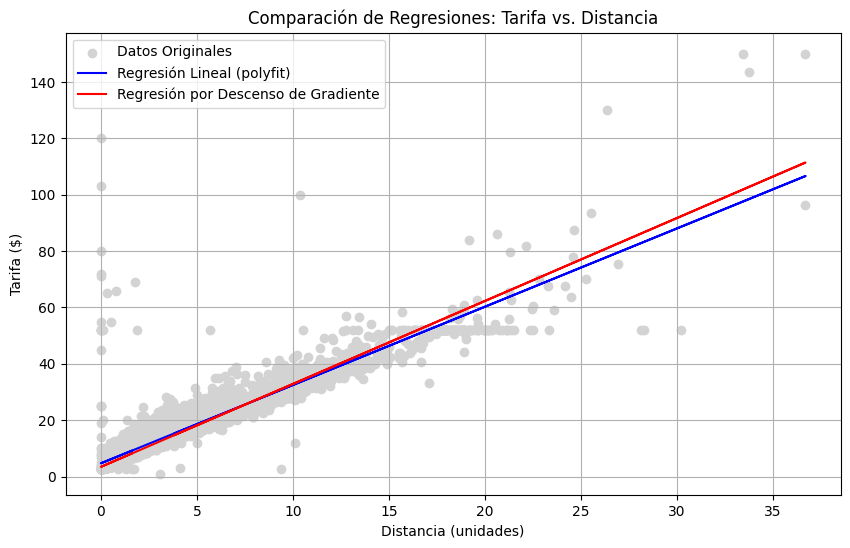

In [61]:
# Visualizar regresiones

plt.figure(figsize=(10, 6))
plt.scatter(x_taxi, y_taxi, color='lightgray', label='Datos Originales')
plt.plot(x_taxi, beta_taxi * x_taxi + alpha_taxi, color='blue', label='Regresión Lineal (polyfit)')
plt.plot(x_taxi, theta_1_taxi * x_taxi + theta_0_taxi, color='red', label='Regresión por Descenso de Gradiente')
plt.xlabel('Distancia (unidades)')
plt.ylabel('Tarifa ($)')
plt.title('Comparación de Regresiones: Tarifa vs. Distancia')
plt.legend()
plt.grid(True)
plt.show()

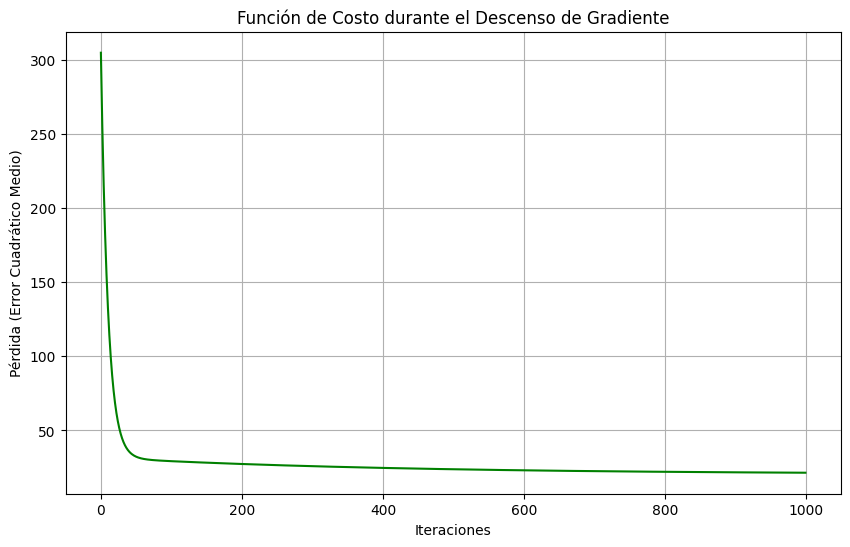

In [62]:
# Visualizar función de costo

plt.figure(figsize=(10, 6))
plt.plot(range(num_iteraciones_taxi), perdida_taxi, color='green')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (Error Cuadrático Medio)')
plt.title('Función de Costo durante el Descenso de Gradiente')
plt.grid(True)
plt.show()